# Model Training and Evaluation

This notebook trains a machine learning model to predict hiring decisions
and evaluates its performance on unseen test data.

## Loading the Preprocessed Data

The cleaned recruitment dataset and the training and testing data prepared
during preprocessing are used for model development and evaluation.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_recruitment.csv")

target = "Hiring_Decision"

protected_attribute = "Gender"

features = [
    "Age",
    "Education_Level",
    "Experience_Years",
    "Skill_Score",
    "Aptitude_Test_Score",
    "Technical_Test_Score",
    "Communication_Score",
    "Certifications_Count",
    "Previous_Companies",
    "Interview_Score",
    "Location",
    "Job_Role_Applied",
    "Expected_Salary"
]

X = df[features]
y = df[target]

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((95976, 13), (23995, 13))

## Preparing Categorical Variables

The model requires numerical inputs, so categorical variables are encoded
using one-hot encoding.

The encoder is fitted only on the training data and then used to transform
both the training and testing data. This prevents information from the test
set from influencing the preprocessing stage.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Education_Level",
    "Location",
    "Job_Role_Applied"
]

numerical_features = [
    "Age",
    "Experience_Years",
    "Skill_Score",
    "Aptitude_Test_Score",
    "Technical_Test_Score",
    "Communication_Score",
    "Certifications_Count",
    "Previous_Companies",
    "Interview_Score",
    "Expected_Salary"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((95976, 23), (23995, 23))

## Training the Logistic Regression Model

A Logistic Regression model is trained to predict the binary `Hiring_Decision`
of candidates. The model is trained using only the training data and its
predictions are later evaluated on the unseen test data.

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

## Making Predictions

The trained model is used to predict hiring decisions for the test dataset.
Because the test data was not used during model training, these predictions
represent the model's performance on unseen candidates.

In [14]:
y_pred = model.predict(X_test_processed)

y_pred[:10]

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1])

## Evaluating Model Performance

The model's predictions are compared with the actual hiring decisions in the
test dataset. Accuracy, precision, recall, and F1-score are used to evaluate
classification performance.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

accuracy, precision, recall, f1

(0.9854969785371952,
 0.9710683691611444,
 0.9726404403432086,
 0.9718537690067939)

## Confusion Matrix

A confusion matrix shows how the model's predictions are distributed across
true positives, true negatives, false positives, and false negatives.

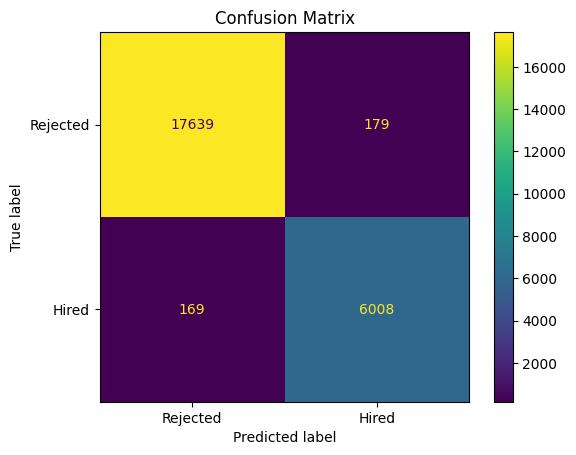

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Hired"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Saving Model Predictions

The actual and predicted hiring decisions are saved together with the
corresponding protected attribute, `Gender`. These results will be used in
the fairness analysis.

In [17]:
results = X_test.copy()

results["Actual_Hiring_Decision"] = y_test
results["Predicted_Hiring_Decision"] = y_pred

results["Gender"] = df.loc[X_test.index, "Gender"]

results.to_csv("../result/model_predictions.csv", index=True)

results.head()

,Age,Education_Level,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Location,Job_Role_Applied,Expected_Salary,Actual_Hiring_Decision,Predicted_Hiring_Decision,Gender
41730,21,Bachelors,14,86,73,79,8,1.0,4,54,Rural,HR Executive,144879,1,1,Male
78138,43,High School,13,13,24,48,46,0.0,1,0,Semi-Urban,Manager,22572,0,0,Male
112634,22,Bachelors,2,34,40,88,1,9.0,6,43,Urban,ML Engineer,101647,0,0,Male
76022,26,High School,11,84,18,27,69,4.0,5,72,Semi-Urban,HR Executive,78336,0,0,Female
64694,38,High School,9,28,43,54,67,7.0,5,69,Semi-Urban,HR Executive,58113,0,0,Female
